# Heart Disease Dataset — EDA & Model Training
Ein vollständiges Data-Science-Workflow-Notebook: Explorative Datenanalyse, Feature Engineering, Modelltraining und Vergleich.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (8, 5)
print('Imports erfolgreich.')

Imports erfolgreich.


## 2. Daten laden

In [2]:
df = pd.read_csv('../data/heart.xls')
print(f'Shape: {df.shape}')
df.head()

Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 3. EDA — Überblick

In [3]:
print('=== Shape ===')
print(df.shape)

print('\n=== Info ===')
df.info()

=== Shape ===
(1025, 14)

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
print('=== Statistische Kennzahlen ===')
df.describe()

=== Statistische Kennzahlen ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
print('=== Fehlende Werte pro Spalte ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'Keine fehlenden Werte gefunden.')

=== Fehlende Werte pro Spalte ===
Keine fehlenden Werte gefunden.


## 4. EDA — Visualisierungen

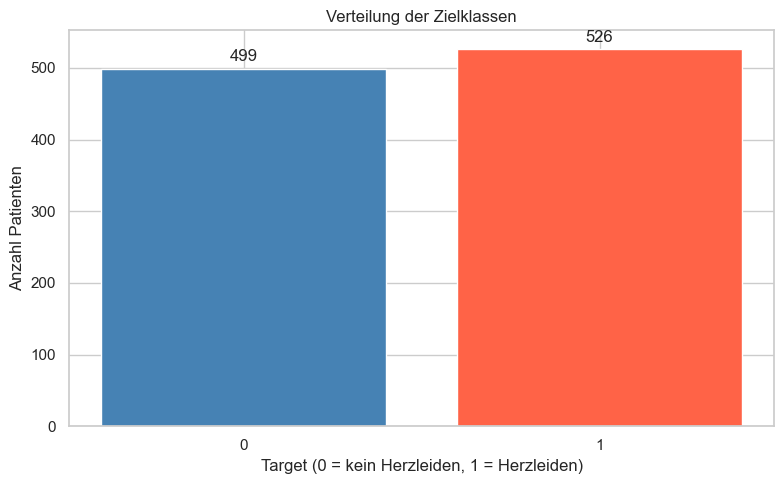

In [6]:
# Zielklassen-Verteilung
target_col = 'target'

fig, ax = plt.subplots()
counts = df[target_col].value_counts().sort_index()
bars = ax.bar(counts.index.astype(str), counts.values, color=['steelblue', 'tomato'], edgecolor='white')
ax.bar_label(bars, padding=3)
ax.set_title('Verteilung der Zielklassen')
ax.set_xlabel('Target (0 = kein Herzleiden, 1 = Herzleiden)')
ax.set_ylabel('Anzahl Patienten')
plt.tight_layout()
plt.show()

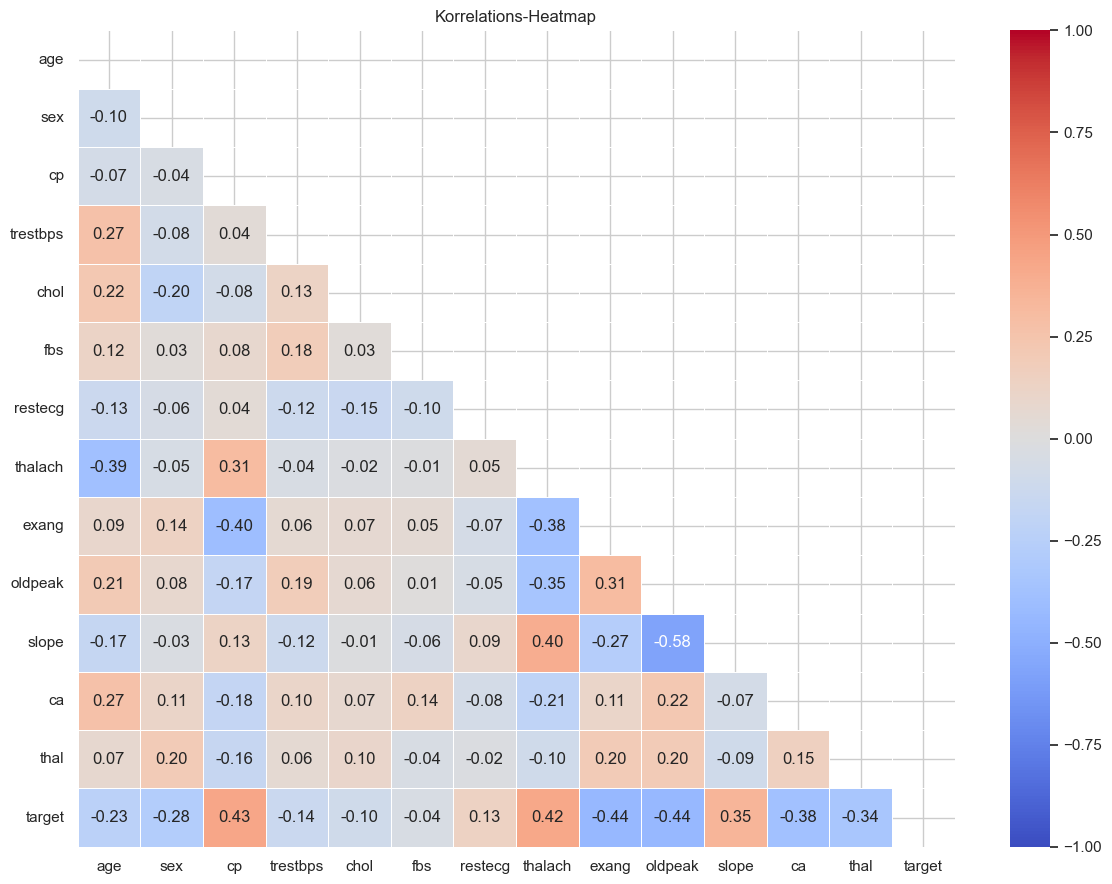

In [7]:
# Korrelations-Heatmap
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, ax=ax, vmin=-1, vmax=1
)
ax.set_title('Korrelations-Heatmap')
plt.tight_layout()
plt.show()

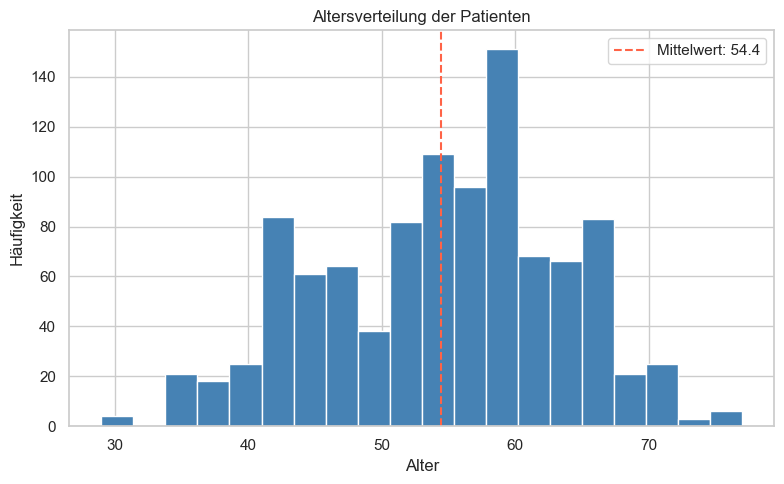

In [8]:
# Alter-Histogramm
age_col = 'age'

fig, ax = plt.subplots()
ax.hist(df[age_col], bins=20, color='steelblue', edgecolor='white')
ax.axvline(df[age_col].mean(), color='tomato', linestyle='--', label=f'Mittelwert: {df[age_col].mean():.1f}')
ax.set_title('Altersverteilung der Patienten')
ax.set_xlabel('Alter')
ax.set_ylabel('Häufigkeit')
ax.legend()
plt.tight_layout()
plt.show()

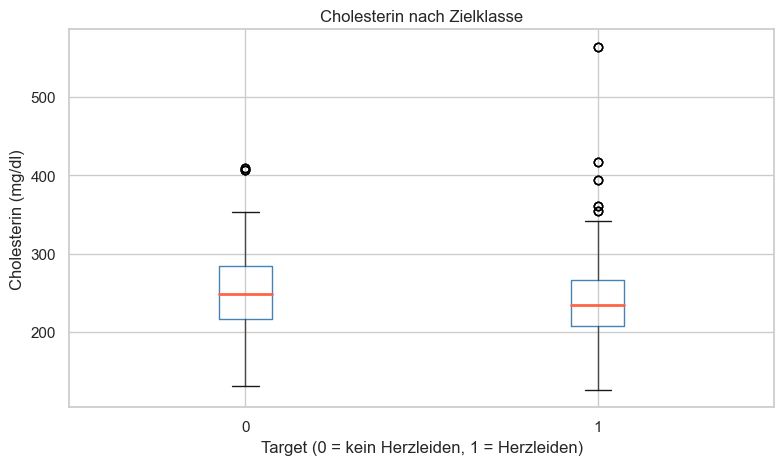

In [9]:
# Boxplot Cholesterin nach Zielklasse
chol_col = 'chol'

fig, ax = plt.subplots()
df.boxplot(column=chol_col, by=target_col, ax=ax,
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='tomato', linewidth=2))
ax.set_title('Cholesterin nach Zielklasse')
ax.set_xlabel('Target (0 = kein Herzleiden, 1 = Herzleiden)')
ax.set_ylabel('Cholesterin (mg/dl)')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 5. Feature Engineering & Train/Test-Split

In [10]:
X = df.drop(columns=[target_col])
y = df[target_col]

print(f'Features: {X.shape[1]} Spalten, {X.shape[0]} Zeilen')
print(f'Zielklasse: {y.name} — Wertebereich: {sorted(y.unique())}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTraining-Set: {X_train.shape[0]} Samples')
print(f'Test-Set:     {X_test.shape[0]} Samples')

# Skalierung für Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Features: 13 Spalten, 1025 Zeilen
Zielklasse: target — Wertebereich: [0, 1]

Training-Set: 820 Samples
Test-Set:     205 Samples


## 6. Modell 1 — Logistic Regression

In [11]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f'Logistic Regression — Accuracy: {acc_lr:.4f}\n')
print(classification_report(y_test, y_pred_lr, target_names=['kein Herzleiden', 'Herzleiden']))

Logistic Regression — Accuracy: 0.8098

                 precision    recall  f1-score   support

kein Herzleiden       0.89      0.70      0.78       100
     Herzleiden       0.76      0.91      0.83       105

       accuracy                           0.81       205
      macro avg       0.82      0.81      0.81       205
   weighted avg       0.82      0.81      0.81       205



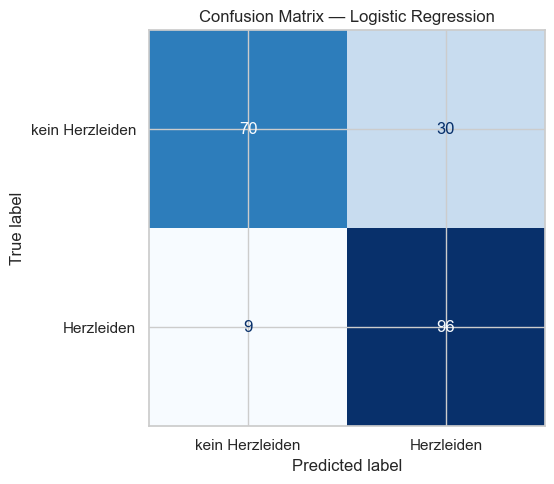

In [12]:
fig, ax = plt.subplots()
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['kein Herzleiden', 'Herzleiden']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

## 7. Modell 2 — Random Forest

In [ ]:
rf = RandomForestClassifier(max_depth=3, n_estimators=50, min_samples_leaf=10, random_state=42)
rf.fit(X_train, y_train)  # Random Forest benötigt keine Skalierung
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest — Accuracy: {acc_rf:.4f}\n')
print(classification_report(y_test, y_pred_rf, target_names=['kein Herzleiden', 'Herzleiden']))

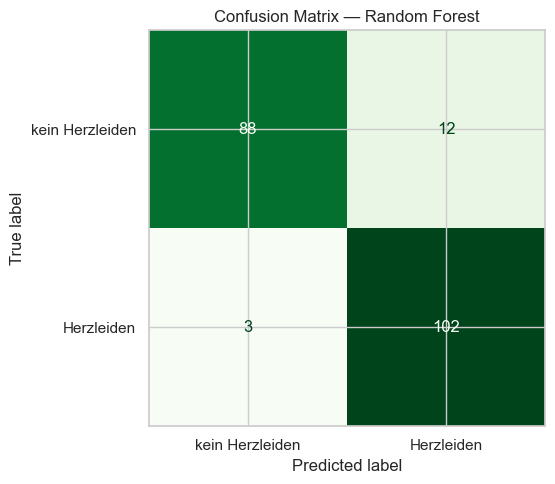

In [14]:
fig, ax = plt.subplots()
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['kein Herzleiden', 'Herzleiden']).plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

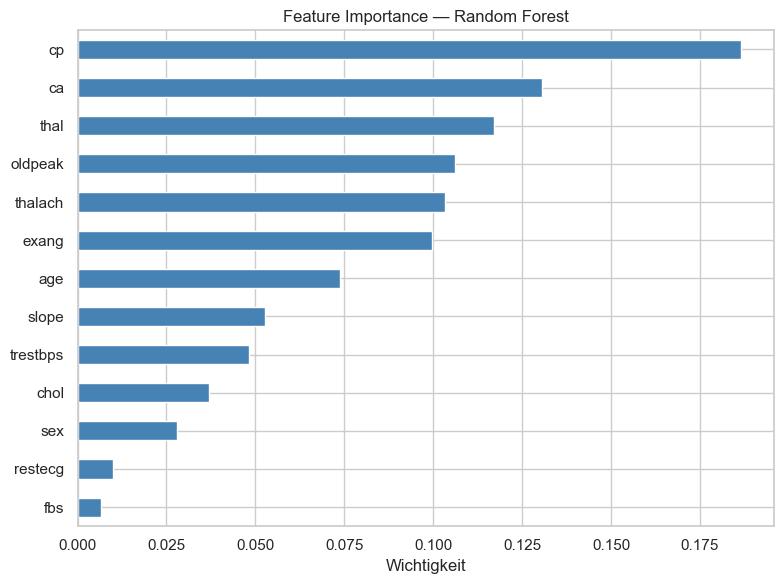

In [15]:
# Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importance — Random Forest')
ax.set_xlabel('Wichtigkeit')
plt.tight_layout()
plt.show()

## 8. Modellvergleich

In [16]:
def get_metrics(y_true, y_pred, model_name):
    return {
        'Modell':     model_name,
        'Accuracy':   round(accuracy_score(y_true, y_pred), 4),
        'Precision':  round(precision_score(y_true, y_pred), 4),
        'Recall':     round(recall_score(y_true, y_pred), 4),
        'F1-Score':   round(f1_score(y_true, y_pred), 4),
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_lr, 'Logistic Regression'),
    get_metrics(y_test, y_pred_rf, 'Random Forest'),
]).set_index('Modell')

print('=== Modellvergleich ===')
results.style.highlight_max(axis=0, color='lightgreen')

=== Modellvergleich ===


,Accuracy,Precision,Recall,F1-Score
Modell,,,,
Logistic Regression,0.809800,0.761900,0.914300,0.831200
Random Forest,0.926800,0.894700,0.971400,0.931500


## 9. Bestes Modell speichern

In [17]:
import os

best_name = results['Accuracy'].idxmax()
best_model = lr if best_name == 'Logistic Regression' else rf
print(f'Bestes Modell: {best_name} (Accuracy: {results.loc[best_name, "Accuracy"]})')

os.makedirs('../models', exist_ok=True)
MODEL_PATH = '../models/best_model.pkl'
joblib.dump(best_model, MODEL_PATH)
print(f'Modell gespeichert unter: {MODEL_PATH}')

# Scaler ebenfalls speichern (wird für Logistic Regression benötigt)
if best_name == 'Logistic Regression':
    joblib.dump(scaler, '../models/scaler.pkl')
    print('Scaler gespeichert unter: ../models/scaler.pkl')

Bestes Modell: Random Forest (Accuracy: 0.9268)
Modell gespeichert unter: ../models/best_model.pkl
